<a href="https://colab.research.google.com/github/alejaagoez-rgb/Analysis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [ ]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:

# mostrar las primeras 5 filas de users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:

# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users


print(users.isna().sum())
print()
print(users.isna().mean())



user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:

# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean())



id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**:

**Usurs**:
- city: presenta 469 valores nulos (11.73%). Recomiendo conservar la columna e investigar los valores faltantes, ya que puede ser útil para segmentar clientes y analizar patrones geográficos en México y Colombia.
- churn_date: presenta 3,534 valores nulos (88.35%). Los nulos probablemente indican que el usuario continúa activo. Recomiendo conservar los nulos y crear una nueva variable status que clasifique a los usuarios como "Activo" o "Dado de baja", facilitando el análisis de abandono.

**Usage**:
- date: presenta 50 valores nulos (0.125%). Recomiendo ignorar estos registros, ya que el porcentaje de valores faltantes es muy bajo.
- duration: presenta 22,076 valores nulos (55.19%). Recomiendo ignorar los nulos, ya que pueden ser esperados según el tipo de interacción. Por ejemplo, una interacción de texto no necesita tener una duración.
- length: presenta 17,896 valores nulos (44.74%). Recomiendo ignorar los nulos, ya que pueden ser esperados según el tipo de interacción. Por ejemplo, una llamada puede no tener un valor de longitud.
En ambos casos (duration y length), recomiendo analizar los valores nulos en función de la columna type, para comprobar que los faltantes corresponden al comportamiento esperado de cada tipo de interacción.


💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.
-
El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users

users.describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` presenta un rango consecutivo entre 10,000 y 13,999, con una media de 11,999.5 y distribución uniforme. No se observan valores extremos ni inconsistencias, lo que confirma que puede utilizarse directamente en el análisis sin necesidad de limpieza adicional.
- La columna `age` muestra un valor mínimo anómalo de -999, que no corresponde a una edad real y afecta la dispersión de los datos (desviación estándar ≈123). Este registro debe tratarse como error o valor faltante antes de continuar con el análisis. En contraste, el resto de los valores (32–79 años) son plausibles y pueden aprovecharse en el estudio

In [ ]:

# explorar columnas numéricas de usage

usage.describe()



,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id`se distribuye de manera consecutiva entre 1 y 40,000, con media ≈20,000.5 y desviación estándar ≈11,547. No presenta valores anómalos ni inconsistencias, lo que confirma que corresponde a un identificador secuencial. Puede utilizarse directamente en el análisis sin necesidad de limpieza adicional
- Las columnas user_id se encuentra en el rango de 10,000 a 13,999, con media ≈12,002 y desviación estándar ≈1,157. La distribución es uniforme y no muestra valores extremos ni errores. Al igual que id, puede emplearse directamente en el análisis, ya que cumple la función de identificador sin requerir ajustes.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

print(users[columnas_user].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` contiene 7 ciudades distintas, con un total de 3,531 registros. La ciudad más frecuente es Bogotá, con 808 usuarios, lo que representa la mayor concentración geográfica en la base. Este hallazgo sugiere que Bogotá es el mercado principal y debe considerarse como foco estratégico en análisis y segmentación.
- La columna `plan` presenta 2 categorías: Básico y Premium, con un total de 4,000 registros. El plan Básico es el más frecuente, con 2,595 usuarios, lo que equivale a casi dos tercios de la base. Este resultado confirma que el plan Básico concentra la mayor parte de clientes y que el Premium requiere estrategias de diferenciación y valor agregado para aumentar su adopción.

In [ ]:
# explorar columna categórica de usage

print(usage['type'].describe())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` La variable type contiene 40,000 registros y 2 categorías únicas. La categoría más frecuente es text, con 22,092 ocurrencias, lo que representa más de la mitad de los registros. Esto indica que el uso de mensajes de texto predomina sobre otros tipos de comunicación en la base, reflejando un patrón claro de preferencia por este canal.

---
✍️ **Comentario**:
- Age:se encontró el valor -999, que no corresponde a una edad real. Este es un claro sentinel o marcador de dato faltante/erróneo.
La recomendación es reemplazar el valor -999 por NaN para que sea tratado como dato faltante en los análisis y posteriormente decidir si se imputará (ej. con mediana o media por grupo) o si se excluirá del análisis, dependiendo del objetivo del estudio.
- Otras columnas revisadas (id, user_id, city, plan, type): no presentan valores inválidos, ya que son identificadores o categorías válidas. Se recomienda únicamente verificar consistencia en categorías (ej. evitar duplicados por errores de escritura o mayúsculas/minúsculas).
**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
print("Año:", users['reg_date'].dt.year.unique())

Año: [2022 2026 2023 2024]


En `reg_date` se puede observar los años que aparecen son 2022, 2023, 2024 y 2026.Esto indica que los registros de usuarios se distribuyen en esos cuatro años.
La presencia de 2026 puede ser un dato llamativo: o bien corresponde a registros proyectados/futuros, o es un error de captura que conviene revisar.

In [ ]:
# Revisar los años presentes en `date` de usage

print("Años presentes:", usage['date'].dt.year.unique())


Años presentes: [2024.   nan]


En `date`concentra registros en 2024, pero presenta valores faltantes (NaN) que deben ser tratados antes de cualquier análisis temporal. Se recomienda conservar los registros válidos y definir una estrategia clara para manejar los faltantes, ya sea imputación o exclusión, según el objetivo del estudio

✍️ **Comentario**: El análisis se centrará en los registros correspondientes al año 2024. Durante la revisión de calidad de los datos, se identificaron registros con fechas futuras (2026) en la variable reg_date, los cuales deberán ser validados y, de confirmarse como inconsistencias, excluidos del análisis. En cuanto a los valores faltantes en date, se conservarán inicialmente para evitar la pérdida de información relevante sobre el uso. Posteriormente, se evaluará la estrategia más adecuada para su tratamiento, ya sea considerándolos como una categoría independiente o aplicando un método de imputación, dependiendo del análisis a realizar.

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
numeric_sentinels = [-999]
users['age'] = users['age'].replace(numeric_sentinels, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
text_sentinels = ["?"]
users['city'] = users['city'].replace(text_sentinels , pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:


# Marcar fechas futuras como NA para reg_date
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT

# Verificar cambios

users["reg_date"].dt.year.value_counts()


2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

## 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration


usage["duration_null"] = usage["duration"].isna()

print(usage.groupby("type")["duration_null"].sum())



type
call        0
text    22076
Name: duration_null, dtype: int64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length

usage["length_null"] = usage["length"].isna()

print(usage.groupby("type")["length_null"].sum())


type
call    17896
text        0
Name: length_null, dtype: int64


**Diagnóstico MAR**:
- duration: presenta 22.076 valores nulos en las interacciones de tipo text y 0 en call. Los nulos dependen de type, ya que los mensajes de texto no tienen duración. Recomiendo ignorar y mantener los valores nulos, porque representan información que no aplica.
- length: presenta 17.896 valores nulos en las interacciones de tipo call y 0 en text. Los nulos dependen de type, ya que las llamadas no tienen longitud de mensaje. Recomiendo ignorar y mantener los valores nulos, porque representan información que no aplica.

**Conclusión**: Los valores nulos de duration y length están relacionados con el tipo de interacción y siguen un patrón esperado. Por lo tanto, no se deben imputar ni eliminar, sino mantener como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text", "is_call", "duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas

usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas

user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:


# Distribución porcentual del tipo de plan

user_profile["plan"].value_counts(normalize=True) * 100



Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

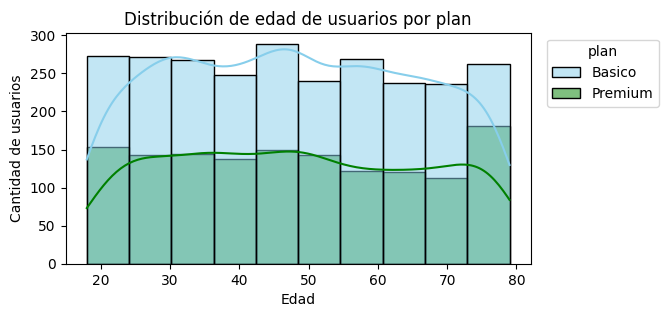

In [ ]:
# Histograma para visualizar la edad (age)


plt.figure(figsize=(6, 3))

ax = sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=10,
    kde=True
)

plt.title("Distribución de edad de usuarios por plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")

ax.legend_.set_bbox_to_anchor((1.02, 1))
ax.legend_._loc = 2

plt.show()


💡Insights:
- La distribución de usuarios por edad dentro de cada plan se mantiene estable y ligeramente ondulada entre los distintos rangos, sin un sesgo etario marcado; en paralelo, el plan Básico concentra el 65% de la base total frente al 35% del Premium. En conjunto, estos hallazgos sugieren que ambos patrones conviven de manera independiente, mostrando diferencias en volumen pero no en perfil etario.

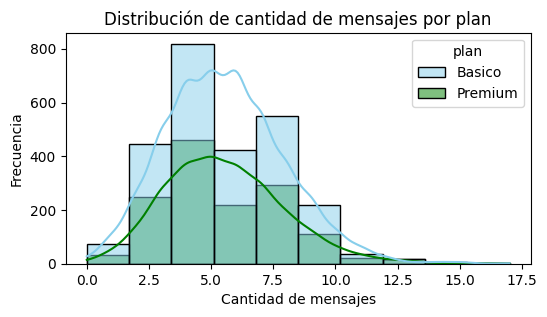

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(6, 3))

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10,
    kde=True
)
plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()



💡Insights:
- "La distribución de mensajes por usuario es sesgada a la derecha en ambos planes, con la mayoría enviando pocos mensajes y una minoría concentrando volúmenes altos; las curvas de Básico y Premium son similares en forma, aunque muestran diferencias sutiles en el punto de mayor concentración y en la dispersión. Estos hallazgos sugieren que las variaciones podrían estar relacionadas con el tamaño de la base más que con un perfil de actividad distinto."

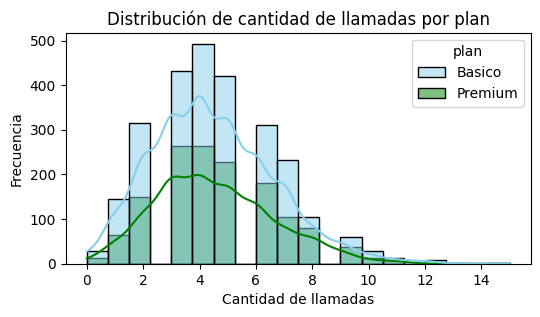

In [ ]:
# Histograma para visualizar la cant_llamadas

plt.figure(figsize=(6, 3))

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=20,
    kde=True
)
plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- La distribución de llamadas en ambos planes presenta un sesgo a la derecha, con un pico claro en 4–5 llamadas y una cola que se extiende hacia valores más altos (hasta 14–15), lo que indica que la mayoría de usuarios concentra su actividad en pocas llamadas pero existe un grupo reducido con volúmenes mayores; además, la mayor frecuencia observada en el plan Básico se explica principalmente por su mayor número de usuarios (11,560 frente a 6,348 en Premium), ya que el promedio de cantidad de llamadas por usuario es prácticamente igual en ambos (≈4.45 vs. ≈4.52), por lo que la conclusión es que el Básico concentra la base más amplia de clientes mientras que el Premium no muestra diferencias significativas en uso individual, lo que obliga a enfocar la estrategia en retención del Básico y en redefinir el valor diferencial del Premium más allá del volumen de llamadas.

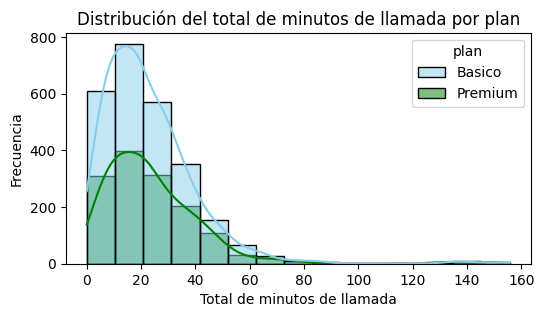

In [ ]:
# Histograma para visualizar la cant_minutos_llamada

plt.figure(figsize=(6, 3))

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15,
    kde=True
)
plt.title('Distribución del total de minutos de llamada por plan')
plt.xlabel('Total de minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- "La distribución del total de minutos de llamada es sesgada a la derecha en ambos planes: la mayoría de usuarios acumula pocos minutos y solo una minoría concentra volúmenes altos. Las curvas de Básico y Premium son similares en forma, con picos en rangos bajos (10–20 minutos), aunque muestran diferencias sutiles en altura y dispersión. En particular, la curva Premium aparece más aplanada y extendida hacia la derecha, lo que sugiere que podría haber una mayor proporción relativa de usuarios con muchos minutos en Premium. Esta hipótesis es consistente con la lectura visual del gráfico, pero requeriría validación estadística adicional para confirmarse."

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

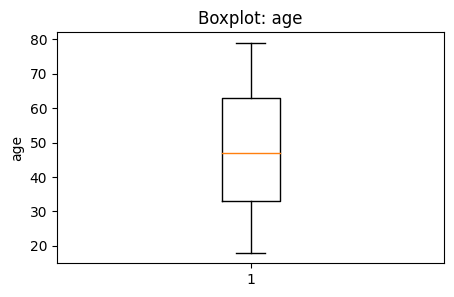

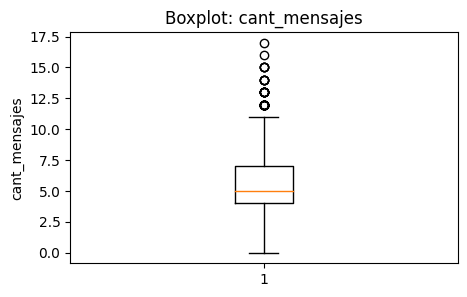

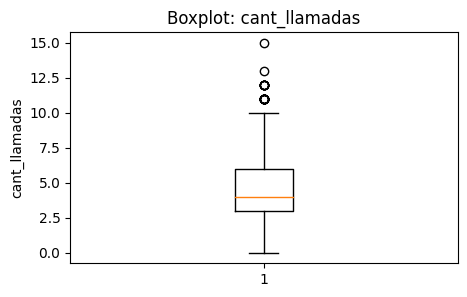

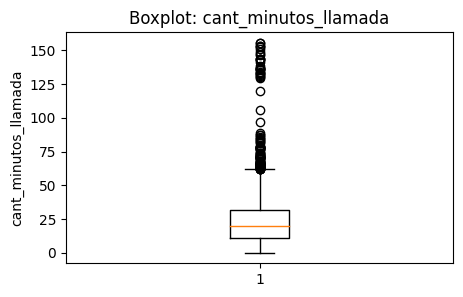

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(5, 3))
    plt.boxplot(user_profile[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()

💡Insights:
- Age:La variable edad no se aprecian puntos aislados fuera de los bigotes, lo que significa que no hay outliers evidentes en la variable de edad bajo el criterio visual del boxplot.
- cant_mensajes:La variable cant_mensajes presenta valores extremos en el lado superior de la distribución, visibles como puntos aislados fuera de los bigotes del boxplot. Esto significa que existen usuarios con un número de mensajes significativamente mayor al resto, lo que podría distorsionar medidas de tendencia central si no se controla. En consecuencia, los análisis posteriores deberían considerar estos outliers: ya sea revisarlos para confirmar si son registros válidos (heavy users) o aplicar técnicas de limpieza/segmentación para evitar sesgos en los resultados.
- cant_llamadas: La variable cant_llamadas presenta valores extremos en el lado superior de la distribución, visibles como puntos aislados fuera de los bigotes del boxplot. Esto indica que existen usuarios con un número de llamadas significativamente mayor al resto, lo que podría sesgar medidas como el promedio si no se controla. En consecuencia, los análisis posteriores deberían considerar estos outliers: revisarlos para confirmar si son registros válidos (usuarios intensivos en llamadas) o aplicar técnicas de limpieza/segmentación para evitar que distorsionen los resultados.
- cant_minutos_llamada:La variable total_minutos_llamada presenta múltiples valores extremos en el lado superior de la distribución, visibles como puntos aislados fuera de los bigotes del boxplot. Esto indica que existe un grupo de usuarios con volúmenes de minutos de llamada significativamente mayores al resto, lo que podría sesgar medidas como el promedio si no se controla. En consecuencia, los análisis posteriores deberían considerar estos outliers: revisarlos para confirmar si son registros válidos (heavy users) o aplicar técnicas de limpieza/segmentación para evitar que distorsionen los resultados

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    outliers_superiores = user_profile[user_profile[col] > limite_superior]

    print(f'\n{col}')
    print(f'Límite superior: {limite_superior}')
    print(f'Outliers superiores: {len(outliers_superiores)}')




cant_mensajes
Límite superior: 11.5
Outliers superiores: 46

cant_llamadas
Límite superior: 10.5
Outliers superiores: 30

cant_minutos_llamada
Límite superior: 61.8575
Outliers superiores: 109


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: La variable cant_mensajes presenta 46 outliers superiores, con valores máximos de 17 frente a un límite IQR de 11.5. Dado que la diferencia es relativamente pequeña y refleja usuarios con un número de mensajes algo mayor al resto, se decidió mantenerlos en el análisis. Estos casos corresponden a heavy users plausibles y no a errores de captura, por lo que aportan información valiosa sobre comportamientos intensivos.
- cant_llamadas:La variable cant_llamadas muestra 30 outliers superiores, con un máximo de 15 frente a un límite IQR de 10.5. La diferencia es reducida y representa usuarios con más llamadas de lo habitual, pero dentro de un rango razonable. Por ello, se decidió mantenerlos en el análisis, tratándolos como un segmento intensivo de uso que refleja variabilidad real en la base de clientes
- cant_minutos_llamada:La variable total_minutos_llamada concentra 109 outliers superiores, con un máximo de 155.7 frente a un límite IQR de 61.9. La diferencia es amplia y genera una cola larga que puede distorsionar medidas globales. En este caso, se decidió no eliminar registros, pero aplicar winsorización en el límite superior para recortar los valores extremos. Esta estrategia conserva la información de los heavy users, pero evita que sesguen los resultados generales, logrando una distribución más representativa del comportamiento típico

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso

user_profile['grupo_uso'] = np.select(
    [
        (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
    ],
    [
        'Bajo uso',
        'Uso medio'
    ],
    default='Alto uso'
)


# Cantidad de usuarios por grupo de uso
cantidad_uso = user_profile['grupo_uso'].value_counts()

# Porcentaje de usuarios por grupo de uso
porcentaje_uso = user_profile['grupo_uso'].value_counts(normalize=True) * 100

# Crear tabla resumen
resumen_uso = pd.DataFrame({
    'Cantidad de usuarios': cantidad_uso,
    'Porcentaje': porcentaje_uso.round(2)
})

resumen_uso

plan_uso = pd.crosstab(
    user_profile['plan'],
    user_profile['grupo_uso'],
    normalize='index'
) * 100

plan_uso.round(2)

print(resumen_uso)
print()
print(plan_uso)

           Cantidad de usuarios  Porcentaje
Uso medio                  2943       73.58
Bajo uso                    778       19.45
Alto uso                    279        6.98

grupo_uso  Alto uso   Bajo uso  Uso medio
plan                                     
Basico     7.167630  19.730250  73.102119
Premium    6.619217  18.932384  74.448399


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.select(
    [
        user_profile['age'] < 30,
        user_profile['age'] < 60
    ],
    [
        'Joven',
        'Adulto'
    ],
    default='Adulto Mayor'
)

# Cantidad de usuarios por grupo de edad
cantidad_edad = user_profile['grupo_edad'].value_counts()

# Porcentaje de usuarios por grupo de edad
porcentaje_edad = user_profile['grupo_edad'].value_counts(normalize=True) * 100

# Crear tabla resumen
resumen_edad = pd.DataFrame({
    'Cantidad de usuarios': cantidad_edad,
    'Porcentaje': porcentaje_edad.round(2)
})

resumen_edad

# Cruce entre grupo de edad y grupo de uso

cruce_edad_uso = pd.crosstab(
    user_profile['grupo_edad'],
    user_profile['grupo_uso']
)

cruce_edad_uso

# Porcentaje de nivel de uso dentro de cada grupo de edad

cruce_porcentaje = pd.crosstab(
    user_profile['grupo_edad'],
    user_profile['grupo_uso'],
    normalize='index'
) * 100

cruce_porcentaje.round(2)

# Edad según el plan
plan_edad = pd.crosstab(
    user_profile['plan'],
    user_profile['grupo_edad'],
    normalize='index'
) * 100

plan_edad.round(2)

print(resumen_edad)
print()
print(cruce_edad_uso)
print()
print(cruce_porcentaje.round(2))
print()
print(plan_edad.round(2))


              Cantidad de usuarios  Porcentaje
Adulto                        2018       50.45
Adulto Mayor                  1222       30.55
Joven                          760       19.00

grupo_uso     Alto uso  Bajo uso  Uso medio
grupo_edad                                 
Adulto             154       364       1500
Adulto Mayor        74       257        891
Joven               51       157        552

grupo_uso     Alto uso  Bajo uso  Uso medio
grupo_edad                                 
Adulto            7.63     18.04      74.33
Adulto Mayor      6.06     21.03      72.91
Joven             6.71     20.66      72.63

grupo_edad  Adulto  Adulto Mayor  Joven
plan                                   
Basico       51.06         30.21  18.73
Premium      49.32         31.17  19.50


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

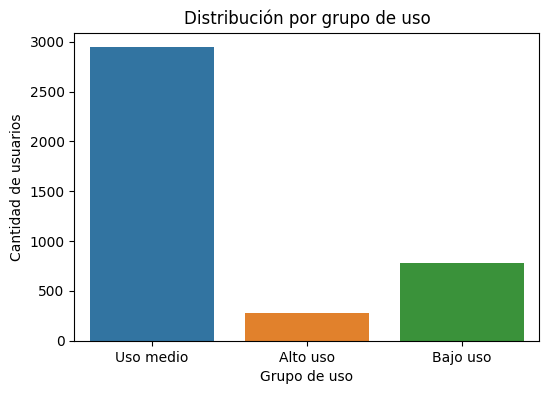

In [ ]:
# Visualización de los segmentos por uso

plt.figure(figsize=(6, 4))
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

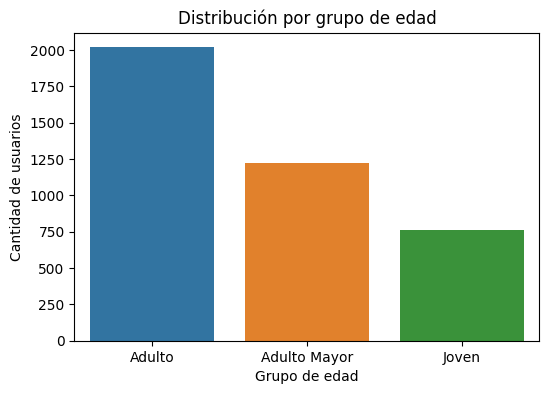

In [ ]:
# Visualización de los segmentos por edad

plt.figure(figsize=(6, 4))
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron 469 valores nulos en la columna city, equivalentes al 11,73 % de los 4.000 usuarios. Aunque no representan una proporción crítica, esta información es relevante para realizar segmentaciones geográficas, por lo que se recomienda conservar la variable y tratar los valores faltantes.
- En la variable age se encontró 1 valor inválido (-999), utilizado como sentinel. Este valor no corresponde a una edad real y podía distorsionar las estadísticas, por lo que fue reemplazado por la mediana.
- La columna churn_date presentó 3.534 valores nulos (88,35 %). Estos valores fueron interpretados como clientes que continúan activos, por lo que no deben eliminarse.
- En usage, la columna date presentó 50 valores nulos (0,125 %). Además, duration presentó 22.076 nulos (55,19 %) y length 17.896 nulos (44,74 %). Estos últimos corresponden al tipo de interacción: los mensajes no requieren duración y las llamadas no requieren longitud, por lo que no representan necesariamente errores.
- También se detectaron registros de reg_date correspondientes a 2026, aunque el análisis está definido hasta 2024. Estos registros fueron tratados como fechas futuras y marcados como nulos para evitar que afectaran los resultados.

🔍 **Segmentos por Edad**

- Se definieron tres segmentos de clientes según su edad:
  Joven: menores de 30 años.
  Adulto: entre 30 y 59 años.
  Adulto Mayor: 60 años o más.
  
La base de clientes está compuesta principalmente por usuarios adultos, quienes representan el 50,45 % de los clientes (2.018 usuarios). Le sigue el segmento de adultos mayores, con 30,55 % (1.222 usuarios), mientras que los jóvenes representan el 19,00 % (760 usuarios).

Esta distribución muestra que ConnectaTel tiene una mayor concentración de clientes adultos y adultos mayores, por lo que las estrategias comerciales y de fidelización deberían considerar las necesidades y patrones de consumo de estos segmentos.

La distribución por edad dentro de los planes Básico y Premium no muestra diferencias etarias marcadas. Por tanto, la principal diferencia entre planes está en el tamaño de la base, no en una concentración clara de un grupo de edad específico. El plan Básico representa aproximadamente 65 % de los clientes, frente a 35 % del Premium.


📊 **Segmentos por Nivel de Uso**

- Los clientes fueron clasificados en tres grupos:

    Bajo uso: menos de 5 llamadas y menos de 5 mensajes.
    Uso medio: menos de 10 llamadas y menos de 10 mensajes.
    Alto uso: clientes que superan los criterios anteriores.

  La mayor parte de los clientes de ConnectaTel se concentra en el segmento de uso medio, con 2.943 usuarios (73,58 %). En segundo lugar se encuentra el segmento de bajo uso, con 778 usuarios (19,45 %), mientras que 279 usuarios (6,98 %) corresponden a alto uso.

Las variables de uso presentan distribuciones sesgadas a la derecha, lo que indica que la mayoría de los clientes tiene un consumo moderado y existe una minoría de usuarios con niveles de actividad significativamente superiores.

En llamadas, el plan Básico presenta una mayor frecuencia absoluta principalmente porque tiene una base de clientes más grande. Sin embargo, el promedio de llamadas por usuario es muy similar entre Básico y Premium, aproximadamente 4,45 frente a 4,52, por lo que no se observa una diferencia importante en el uso individual de llamadas entre ambos planes.


➡️ Esto sugiere que ConnectaTel tiene una base principalmente adulta y de uso medio, mientras que existe un grupo más pequeño de usuarios intensivos que puede representar una oportunidad comercial. El plan Básico concentra la mayor cantidad de clientes, por lo que existe potencial para identificar usuarios de alto consumo dentro de esta base y ofrecerles una migración hacia Premium o una alternativa adaptada a sus necesidades. Al mismo tiempo, los clientes de bajo uso representan una oportunidad para aumentar la frecuencia de utilización mediante estrategias de activación y fidelización.


💡 **Recomendaciones**
- Potenciar la migración de clientes de alto uso: identificar usuarios del segmento Alto uso, especialmente aquellos que actualmente tienen plan Básico, y ofrecerles incentivos para migrar a Premium. Estos clientes presentan un comportamiento de consumo más intenso y pueden tener mayor potencial de generación de ingresos.
- Crear una estrategia de activación para clientes de bajo uso: ofrecer beneficios temporales, paquetes adicionales o campañas personalizadas que incentiven el uso de llamadas y mensajes y reduzcan el riesgo de abandono.
- Reforzar el valor diferencial del plan Premium: dado que el Premium representa aproximadamente el 35 % de la base y el uso promedio de llamadas es similar al Básico, la propuesta Premium debería diferenciarse mediante beneficios adicionales y no únicamente mediante una mayor cantidad de minutos o mensajes incluidos.
- Evaluar un plan intermedio: la concentración del 73,58 % de clientes en uso medio sugiere una oportunidad para diseñar un plan que se adapte mejor a este comportamiento, ofreciendo una cantidad de servicios superior al Básico pero sin llegar necesariamente al nivel de consumo incluido en Premium.
- Gestionar los outliers como un segmento comercial: se detectaron 46 outliers en cantidad de mensajes, 30 en cantidad de llamadas y 109 en minutos de llamadas. Estos usuarios no deben eliminarse automáticamente, porque pueden representar heavy users reales. En particular, los 109 casos de minutos de llamadas presentan una cola más pronunciada, por lo que se aplicó winsorización para evitar que distorsionaran las estadísticas sin perder completamente la información de estos clientes.
- Mejorar la calidad de los datos geográficos: reducir los valores faltantes de city permitiría realizar campañas y estrategias comerciales más precisas por mercado o ciudad.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK https://github.com/alejaagoez-rgb/Analysis-ConnectaTel.git`